# Sweep G from low and high synaptic gating initial conditions

Compare late excitatory and inhibitory firing rates after independent starts at each G.
This notebook uses the AAL connectivity and static-FIC settings from `examples.ipynb`.

- Draw independent per-region `sn0` and `sg0` values from Uniform(0, 0.1) for the low start and Uniform(0.3, 1) for the high start. Draw once with a fixed initialization seed and reuse the same vectors at every G.
- G ranges from 0 to 2.5 in steps of 0.5. Each run lasts 120 s; discard the first 10 s.
- Plasticity and decay are off. J is constant **within** a run and recomputed at each G using `1 + 0.75 * G * C.sum(axis=0)`.
- Noise SD is the model default, 0.01 nA. The same seed is used for all runs, pairing the noise across initial conditions. Set `sigma = 0.0` below for a deterministic comparison.
- Every run resets its initial conditions. States are not passed between neighboring G values.

A persistent difference over this finite window is a candidate for initial-state dependence, not proof of bistability or hysteresis. Inspect transients and repeat with longer durations and additional seeds before making that interpretation. No BOLD signal is computed.

Use the **fasthdmf312** environment with the rebuilt library; restart an already-running kernel first.

In [ ]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastdyn_fic_dmf as dmf

repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent

SC_path = "/network/iss/home/ivan.mindlin/Repos/fastHDMF-code/data/SCs/"
Condition = "DoC"
Scanner = "workbench_siemens"
SC_type = "streamline_count"
Parcellation = "schaefer100"
subject_id = "8009935434"


C = np.loadtxt(repo_root / "data/SCs/Averaged_SCs/aal/healthy_average.csv", delimiter=",")
C = 0.2 * C / C.max()
N = C.shape[0]

print(f"Connectivity: {N} regions, maximum weight = {C.max():.2f}")
print(f"Simulator: {dmf.__file__}")
assert {"sn0", "sg0"} <= dmf.default_params(C=C).keys(), "Use the rebuilt library in fasthdmf312."

Connectivity: 90 regions, maximum weight = 0.20
Simulator: /usr/local/lib/python3.10/dist-packages/fastdyn_fic_dmf/__init__.py


In [9]:
# Calculate the eigenvalues of the connectivity matrix
C = np.loadtxt(repo_root / "data/SCs/Averaged_SCs/aal/healthy_average.csv", delimiter=",")
eigenvalues = np.linalg.eigvals(C)

In [11]:
C.max()

0.8324346932665125

In [10]:
eigenvalues 

array([ 2.72161352,  2.26421609,  2.073027  ,  1.80525122,  1.61779024,
        1.53401789,  1.41951112,  1.30156234,  1.2165216 ,  1.15979468,
        1.02999461,  0.95891806,  0.9098495 ,  0.8794921 ,  0.78287944,
        0.76069931,  0.71123389,  0.67104203,  0.62895912,  0.53792539,
        0.4901081 ,  0.50396831,  0.49839092,  0.39716483,  0.3115084 ,
        0.32592556, -1.08000191,  0.2764886 ,  0.25004441,  0.23538297,
       -0.9831843 ,  0.21592126,  0.19412486,  0.14925481,  0.09544073,
       -0.94792689, -0.93355505, -0.91731664, -0.91120377,  0.07116896,
       -0.89197488,  0.05479908,  0.00348766, -0.87467676, -0.86061921,
       -0.84042861, -0.85221591, -0.01714721, -0.81447162, -0.04013309,
       -0.7898315 , -0.08576357, -0.08836267, -0.11294713, -0.76387032,
       -0.12199861, -0.7703774 , -0.72630502, -0.20350354, -0.17897633,
       -0.17600257, -0.71068284, -0.23077547, -0.68979565, -0.66791309,
       -0.24533358, -0.25908473, -0.28850133, -0.30422776, -0.65

## Sweep G from repeated low and high initial conditions

Keep the sub-critical `w+` and `JGABA` fixed while sweeping only global coupling `G`. 
At every G, run five low and five high initial-condition simulations. Each repetition 
uses independently sampled regional `S_e` (`sn0`) and `S_g` (`sg0`) values; the same 
five draws are reused across G so that changes along the sweep are paired.

Regional excitatory and inhibitory firing rates are averaged over the post-burn-in 
window for every simulation. Peak excitatory rates over that window are retained to 
identify regions that exceed 5 Hz.


In [ ]:
# Parameters found from find_w_JGABA_bistability
w_plus = 2.39 # 0.1 less then the bistable, as in Castro 2020
JGABA = 1.675 

In [12]:
sigma

0.0

110 simulations; fixed w+=2.39, JGABA=1.675; averaging 10–120 s
G=0.0: 5 low and 5 high starts complete
G=0.1: 5 low and 5 high starts complete
G=0.2: 5 low and 5 high starts complete
G=0.3: 5 low and 5 high starts complete
G=0.4: 5 low and 5 high starts complete
G=0.5: 5 low and 5 high starts complete
G=0.6: 5 low and 5 high starts complete
G=0.7: 5 low and 5 high starts complete
G=0.8: 5 low and 5 high starts complete
G=0.9: 5 low and 5 high starts complete
G=1.0: 5 low and 5 high starts complete
Sweep complete in 1293.8 s


,Initial_Condition,n_regions_max_rate_above_5Hz,region_indices
0,low,90,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,high,90,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


,Initial_Condition,G,repeat,mean_rate_e_Hz,mean_rate_i_Hz,n_regions_max_rate_above_5Hz,region_indices
0,low,0.0,1,2.181474,3.564415,0,[]
1,low,0.0,2,2.181474,3.564415,0,[]
2,low,0.0,3,2.181474,3.564415,0,[]
3,low,0.0,4,2.181474,3.564415,0,[]
4,low,0.0,5,2.181474,3.564415,0,[]
...,...,...,...,...,...,...,...
105,high,1.0,1,44.106869,9.635150,90,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
106,high,1.0,2,44.106869,9.635150,90,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
107,high,1.0,3,44.106869,9.635150,90,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
108,high,1.0,4,44.106869,9.635150,90,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


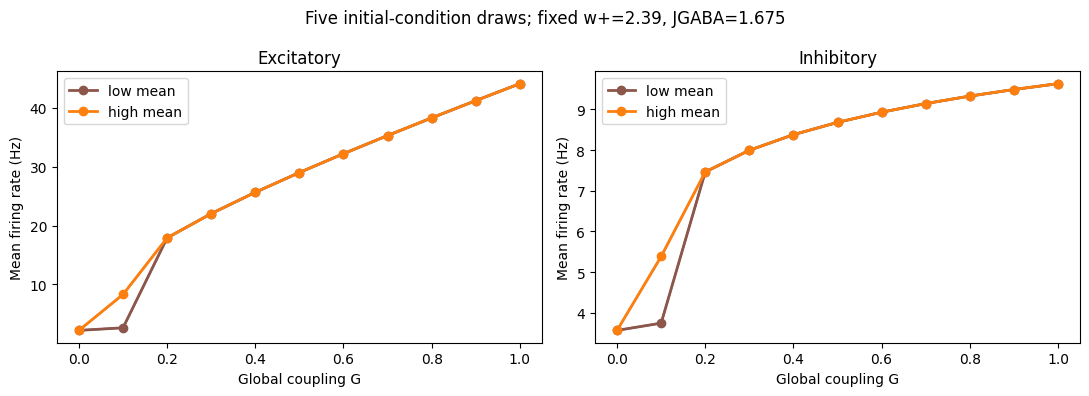

In [5]:
# Full-network G-only sweep with n_repeats paired draws per initial-condition type.
sweep_G_values = np.linspace(0.0, 1.0, 11)
n_repeats = 5
peak_threshold_hz = 5.0
sweep_condition_names = ["low", "high"]
gating_ranges = {"low": (0.0, 0.1), "high": (0.3, 1.0)}

# Draw n_repeats independent regional S_e/S_g vectors for each condition, then reuse
# each draw across G to make differences along the G axis directly comparable.
sweep_rng = np.random.default_rng(initialization_seed)
sweep_initial_conditions = {}
for condition in sweep_condition_names:
    lower, upper = gating_ranges[condition]
    # Move both bounds inward so every sampled value satisfies strict inequalities.
    sample_lower = np.nextafter(lower, upper)
    sample_upper = np.nextafter(upper, lower)
    sweep_initial_conditions[condition] = [
        {"sn0": sweep_rng.uniform(sample_lower, sample_upper, N),
         "sg0": sweep_rng.uniform(sample_lower, sample_upper, N)}
        for _ in range(n_repeats)
    ]

result_shape = (len(sweep_condition_names), len(sweep_G_values), n_repeats, N)
sweep_average_rate_e = np.empty(result_shape)
sweep_average_rate_i = np.empty(result_shape)
sweep_max_rate_e = np.empty(result_shape)

n_simulations = len(sweep_condition_names) * len(sweep_G_values) * n_repeats
print(f"{n_simulations} simulations; fixed w+={w_plus:g}, JGABA={JGABA:g}; "
      f"averaging {burn_in_s:g}–{duration_s:g} s")
sweep_start = perf_counter()
for g_index, G in enumerate(sweep_G_values):
    for condition_index, condition in enumerate(sweep_condition_names):
        for repeat_index, initial_state in enumerate(sweep_initial_conditions[condition]):
            params = dmf.default_params(
                C=C, G=float(G), J=JGABA, w=w_plus, dt=0.1,
                seed=seed + repeat_index, sigma=sigma,
                with_plasticity=False, with_decay=False,
                return_rate=True, return_bold=False, return_fic=False,
                **initial_state,
            )
            rates_e, rates_i, _, _ = dmf.run(params, nb_steps)
            if not (np.isfinite(rates_e).all() and np.isfinite(rates_i).all()):
                raise ValueError(
                    f"Non-finite rates: G={G}, condition={condition}, "
                    f"repeat={repeat_index + 1}"
                )

            post_burn_in_e = rates_e[:, burn_in_steps:]
            post_burn_in_i = rates_i[:, burn_in_steps:]
            sweep_average_rate_e[condition_index, g_index, repeat_index] = (
                post_burn_in_e.mean(axis=1)
            )
            sweep_average_rate_i[condition_index, g_index, repeat_index] = (
                post_burn_in_i.mean(axis=1)
            )
            sweep_max_rate_e[condition_index, g_index, repeat_index] = (
                post_burn_in_e.max(axis=1)
            )
            del rates_e, rates_i, post_burn_in_e, post_burn_in_i

    print(f"G={G:.1f}: 5 low and 5 high starts complete")
print(f"Sweep complete in {perf_counter() - sweep_start:.1f} s")

# One row per simulation: count and extract zero-based region indices whose
# maximum post-burn-in excitatory firing rate exceeded the threshold.
simulation_rows = []
for condition_index, condition in enumerate(sweep_condition_names):
    for g_index, G in enumerate(sweep_G_values):
        for repeat_index in range(n_repeats):
            region_indices = np.flatnonzero(
                sweep_max_rate_e[condition_index, g_index, repeat_index]
                > peak_threshold_hz
            )
            simulation_rows.append({
                "Initial_Condition": condition,
                "G": G,
                "repeat": repeat_index + 1,
                "mean_rate_e_Hz": sweep_average_rate_e[
                    condition_index, g_index, repeat_index
                ].mean(),
                "mean_rate_i_Hz": sweep_average_rate_i[
                    condition_index, g_index, repeat_index
                ].mean(),
                "n_regions_max_rate_above_5Hz": len(region_indices),
                "region_indices": region_indices.tolist(),
            })
simulation_region_summary = pd.DataFrame(simulation_rows)

# Aggregate by Initial_Condition: a region is included if it exceeded 5 Hz in
# at least one G/repetition for that condition.
condition_rows = []
for condition_index, condition in enumerate(sweep_condition_names):
    region_indices = np.flatnonzero(
        sweep_max_rate_e[condition_index].max(axis=(0, 1)) > peak_threshold_hz
    )
    condition_rows.append({
        "Initial_Condition": condition,
        "n_regions_max_rate_above_5Hz": len(region_indices),
        "region_indices": region_indices.tolist(),
    })
initial_condition_region_summary = pd.DataFrame(condition_rows)
display(initial_condition_region_summary)
display(simulation_region_summary)

# Show all n_repeats simulation averages plus their mean for each condition.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, average_rates, population in zip(
    axes, (sweep_average_rate_e, sweep_average_rate_i), ("Excitatory", "Inhibitory")
):
    for condition_index, condition in enumerate(sweep_condition_names):
        network_average = average_rates[condition_index].mean(axis=-1)
        for repeat_index in range(n_repeats):
            ax.plot(sweep_G_values, network_average[:, repeat_index], alpha=0.25)
        ax.plot(sweep_G_values, network_average.mean(axis=1), "o-", linewidth=2,
                label=f"{condition} mean")
    ax.set(xlabel="Global coupling G", ylabel="Mean firing rate (Hz)",
           title=population)
    ax.legend()
fig.suptitle(f"n_repeats initial-condition draws; fixed w+={w_plus:g}, JGABA={JGABA:g}")
fig.tight_layout()
plt.show()


In [63]:
condition = "low"
initial_state = sweep_initial_conditions[condition][0]
G = 2.1
seed = 54
sigma = 0.00 
#nb_steps = int(duration_s / 0.1)
params = dmf.default_params(
    C=C, G=float(G), dt=0.1,
    seed=seed + repeat_index, sigma=sigma,
    with_plasticity=False, with_decay=False,
    return_rate=True, return_bold=False, return_fic=False,
    **initial_state,
)
rates_e, rates_i, _, _ = dmf.run(params, nb_steps)
if not (np.isfinite(rates_e).all() and np.isfinite(rates_i).all()):
    raise ValueError(
        f"Non-finite rates: G={G}, condition={condition}, "
        f"repeat={repeat_index + 1}"
    )

post_burn_in_e = rates_e
post_burn_in_i = rates_i

condition = "high"
initial_state = sweep_initial_conditions[condition][0]
#nb_steps = int(duration_s / 0.1)
params_high = dmf.default_params(
    C=C, G=float(G), dt=0.1,
    seed=seed + repeat_index, sigma=sigma,
    with_plasticity=False, with_decay=False,
    return_rate=True, return_bold=False, return_fic=False,
    **initial_state,
)
rates_e, rates_i, _, _ = dmf.run(params_high, nb_steps)
if not (np.isfinite(rates_e).all() and np.isfinite(rates_i).all()):
    raise ValueError(
        f"Non-finite rates: G={G}, condition={condition}, "
        f"repeat={repeat_index + 1}"
    )

high_post_burn_in_e = rates_e
high_post_burn_in_i = rates_i

In [64]:
rates.shape

(90, 119980)

Text(0.5, 0, 'Time step')

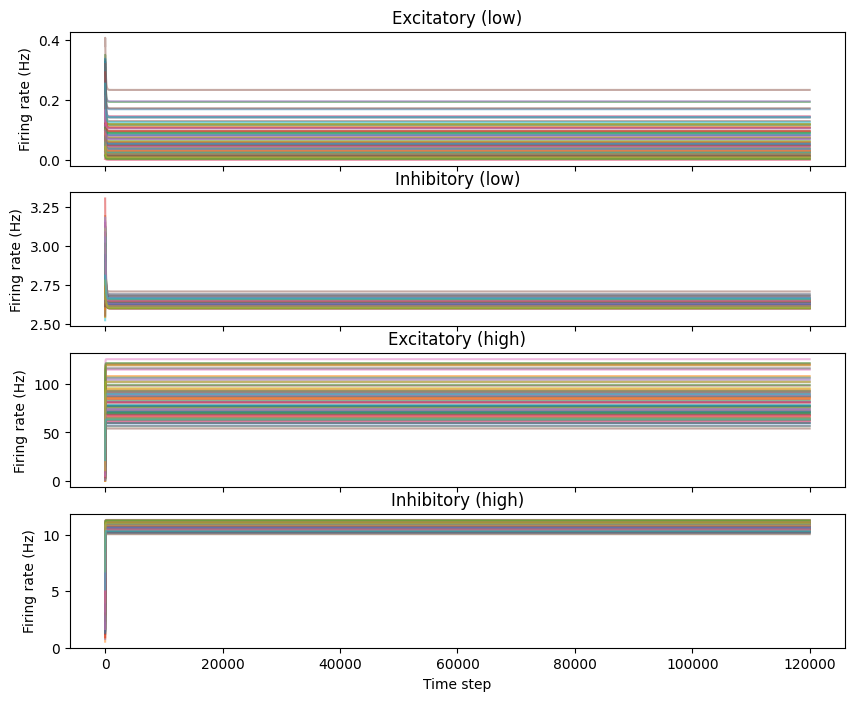

In [65]:
# Plot the post-burn-in excitatory and inhibitory rates for both conditions
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for ax, rates, title in zip(
    axes,
    [post_burn_in_e[:, 20:], post_burn_in_i[:, 20:], high_post_burn_in_e[:, 20:], high_post_burn_in_i[:, 20:]],
    ["Excitatory (low)", "Inhibitory (low)", "Excitatory (high)", "Inhibitory (high)"]
):
    ax.plot(rates.T, alpha=0.5)
    ax.set_ylabel("Firing rate (Hz)")
    ax.set_title(title)
axes[-1].set_xlabel("Time step")
